# L06: IIoT Time Series Forecasting Lab  
### Ruben Valenzuela
### Marques Roberson
### Ezra Bakatubia
### Andrew Kuruvilla


## Introduction
In this lab, we apply time-series forecasting techniques to IoT temperature data. The goal is to preprocess the dataset, engineer relevant features, train forecasting models, evaluate their performance, and enhance the dataset using generative modeling (VAE).

This notebook follows a structured pipeline including data preparation, modeling, evaluation, and augmentation.

## 1. Data Loading and Initial Exploration

In this section, we load the IoT temperature dataset from Kaggle using the KaggleHub API. After downloading the dataset, we inspect its contents and load the CSV file into a pandas DataFrame.

We also preview the dataset to understand its structure, including key columns such as timestamp (`noted_date`) and temperature (`temp`).

In [ ]:
import kagglehub
atulanandjha_temperature_readings_iot_devices_path = kagglehub.dataset_download('atulanandjha/temperature-readings-iot-devices')

print('Data source import complete.')

Using Colab cache for faster access to the 'temperature-readings-iot-devices' dataset.
Data source import complete.


In [ ]:
print(atulanandjha_temperature_readings_iot_devices_path)

/kaggle/input/temperature-readings-iot-devices


In [ ]:
import os

path = atulanandjha_temperature_readings_iot_devices_path
print(os.listdir(path))

['IOT-temp.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/IOT-temp.csv")
df.head()

,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


## 2. Data Inspection and Preprocessing

In this section, we explore the dataset to understand its structure, data types, and statistical properties. We also check for missing values to ensure data quality before modeling.

The dataset contains over 97,000 observations with temperature readings recorded over time. The main variable of interest is `temp`, which represents the temperature values collected by IoT sensors.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97606 entries, 0 to 97605
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          97606 non-null  object
 1   room_id/id  97606 non-null  object
 2   noted_date  97606 non-null  object
 3   temp        97606 non-null  int64 
 4   out/in      97606 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,temp
count,97606.000000
mean,35.053931
std,5.699825
min,21.000000
25%,30.000000
50%,35.000000
75%,40.000000
max,51.000000


The summary statistics show that the temperature values range between 21 and 51 degrees, with an average of approximately 35 degrees. This indicates a relatively stable temperature distribution with moderate variability.

Additionally, no missing values were found in the dataset, which simplifies the preprocessing stage and allows us to proceed directly to feature engineering.

In [ ]:
df.isnull().sum()

,0
id,0
room_id/id,0
noted_date,0
temp,0
out/in,0


## 3. Time-Series Preparation and Feature Engineering

To prepare the data for time-series forecasting, we convert the `noted_date` column into a datetime format and sort the dataset chronologically.

We then select the relevant variables and set the timestamp as the index to properly structure the data for time-series analysis.

In [ ]:
df['noted_date'] = pd.to_datetime(df['noted_date'], format='%d-%m-%Y %H:%M')

In [ ]:
df = df.sort_values(by='noted_date')

In [ ]:
df = df[['noted_date', 'temp']]
df = df.set_index('noted_date')

In [ ]:
df['temp_lag_1'] = df['temp'].shift(1)
df['temp_lag_2'] = df['temp'].shift(2)
df['rolling_mean_3'] = df['temp'].rolling(window=3).mean()

To enhance the model's ability to capture temporal patterns, we create additional features:

- **Lag features (`temp_lag_1`, `temp_lag_2`)**: These represent past temperature values and help the model learn temporal dependencies.
- **Rolling mean (`rolling_mean_3`)**: This feature smooths short-term fluctuations and highlights local trends in the data.

These engineered features improve the model’s understanding of time-based patterns in IoT sensor data.

## 4. Train-Test Split

After preprocessing and feature engineering, the dataset is split into training and testing sets using an 80/20 ratio.

The training set is used to fit the forecasting model, while the testing set is reserved for evaluating model performance on unseen data. This approach helps ensure that the model generalizes well and avoids overfitting.

In [ ]:
df = df.dropna()

In [ ]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [ ]:
!pip install nixtla

## 6. Time-Series Formatting for Forecasting

In this section, the dataset is reformatted to meet the input requirements of the Nixtla forecasting framework.

The data is transformed into a structure with two key columns:
- `ds`: timestamp (datetime index)
- `y`: target variable (temperature)

This standardized format is required for most time-series forecasting libraries.

In [ ]:
# Rebuild clean forecasting dataframe
df_reset = df.reset_index()

df_nixtla = df_reset[['noted_date', 'temp']].copy()
df_nixtla.columns = ['ds', 'y']

# Make sure y is numeric
df_nixtla['y'] = pd.to_numeric(df_nixtla['y'], errors='coerce')

# Resample hourly, interpolate, and remove remaining NaNs
df_nixtla = (
    df_nixtla
    .set_index('ds')
    .resample('h')
    .mean()
    .interpolate(method='linear')
    .dropna()
    .reset_index()
)

print(df_nixtla.isnull().sum())
df_nixtla.head()

ds    0
y     0
dtype: int64


,ds,y
0,2018-07-28 07:00:00,31.395349
1,2018-07-28 08:00:00,31.403438
2,2018-07-28 09:00:00,31.411527
3,2018-07-28 10:00:00,31.419616
4,2018-07-28 11:00:00,31.427705


To ensure data consistency, the temperature column is converted into a numeric format. Any invalid values are coerced into missing values and handled appropriately.

The dataset is then resampled to an hourly frequency to create a uniform time interval. Since real-world IoT data often contains irregular timestamps, interpolation is applied to fill missing values and maintain continuity in the time series.

In [ ]:
train_size = int(len(df_nixtla) * 0.8)
train_df = df_nixtla.iloc[:train_size].copy()
test_df = df_nixtla.iloc[train_size:].copy()

print(train_df.shape, test_df.shape)

(2556, 2) (639, 2)


## 7. Forecasting Model Setup

In this section, we install and configure the StatsForecast library, which provides efficient statistical models for time-series forecasting.

This framework is optimized for performance and scalability, making it suitable for IIoT datasets with large numbers of observations.

In [ ]:
!pip install statsforecast mlforecast utilsforecast

## 8. Train-Test Split for Forecasting

After formatting the dataset for forecasting, a new train-test split is performed using an 80/20 ratio.

The data is split chronologically to preserve the time dependency, ensuring that the model is trained on past data and evaluated on future observations. This is a critical requirement for time-series forecasting tasks.

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

## 9. Preparing Data for StatsForecast

To use the StatsForecast framework, the dataset must follow a specific structure with three required columns:

- `unique_id`: identifier for the time series
- `ds`: timestamp
- `y`: target variable (temperature)

Since this dataset contains a single time series, a constant identifier (`temp_series`) is assigned to all rows.

In [ ]:
train_sf = train_df.copy()
test_sf = test_df.copy()

train_sf['unique_id'] = 'temp_series'
test_sf['unique_id'] = 'temp_series'

train_sf = train_sf[['unique_id', 'ds', 'y']]
test_sf = test_sf[['unique_id', 'ds', 'y']]

## 10. Forecasting Model: SeasonalNaive

In this section, we apply a baseline forecasting model using Nixtla’s StatsForecast library. The selected model is **SeasonalNaive**, which assumes that future values will follow the same pattern observed in previous seasonal cycles.

Given that the data is recorded hourly, a seasonal length of 24 is used to capture daily patterns.

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

sf = StatsForecast(
    models=[SeasonalNaive(season_length=24)],
    freq='h',
    n_jobs=-1
)

forecast = sf.forecast(df=train_sf, h=len(test_sf))
forecast.head()

,unique_id,ds,SeasonalNaive
0,temp_series,2018-11-11 19:00:00,42.933213
1,temp_series,2018-11-11 20:00:00,42.949458
2,temp_series,2018-11-11 21:00:00,42.965704
3,temp_series,2018-11-11 22:00:00,42.981949
4,temp_series,2018-11-11 23:00:00,42.998195


## 11. Model Evaluation

To evaluate the model’s performance, we compare the predicted values against the actual values in the test dataset.

The following evaluation metrics are used:

- **MAE (Mean Absolute Error)**: Measures the average magnitude of errors.
- **MSE (Mean Squared Error)**: Penalizes larger errors more heavily.
- **RMSE (Root Mean Squared Error)**: Provides error in the same unit as the target variable.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = test_sf[['ds', 'y']].merge(
    forecast[['ds', 'SeasonalNaive']],
    on='ds',
    how='left'
)

mae = mean_absolute_error(results['y'], results['SeasonalNaive'])
mse = mean_squared_error(results['y'], results['SeasonalNaive'])
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

results.head()

MAE: 4.649937783414447
MSE: 32.833927631392896
RMSE: 5.730089670449573


,ds,y,SeasonalNaive
0,2018-11-11 19:00:00,43.323105,42.933213
1,2018-11-11 20:00:00,43.339350,42.949458
2,2018-11-11 21:00:00,43.355596,42.965704
3,2018-11-11 22:00:00,43.371841,42.981949
4,2018-11-11 23:00:00,43.388087,42.998195


## 12. Forecast Visualization

To better understand the model’s performance, we visualize the actual temperature values alongside the predicted values generated by the SeasonalNaive model.

This comparison allows us to observe how closely the model follows the real data patterns over time.

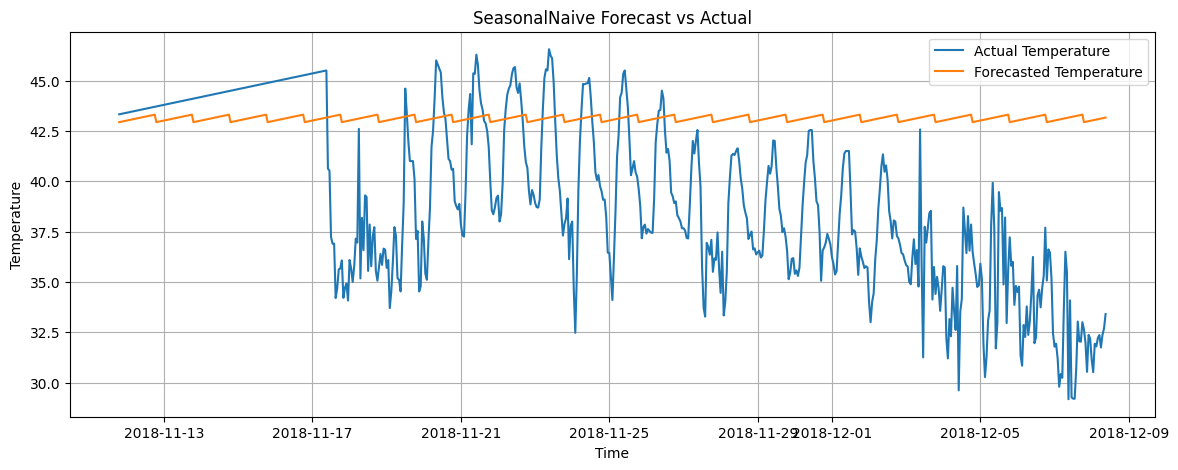

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(results['ds'], results['y'], label='Actual Temperature')
plt.plot(results['ds'], results['SeasonalNaive'], label='Forecasted Temperature')
plt.title('SeasonalNaive Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

The blue line represents the actual temperature readings, while the orange line represents the forecasted values.

From the plot, we can observe that the SeasonalNaive model captures the general level of the data but fails to fully adapt to fluctuations and sudden changes in temperature.

This behavior is expected, as the model simply repeats past seasonal patterns rather than learning dynamic trends.

## 13. Rolling-Origin Cross-Validation

To evaluate the robustness of the forecasting model, we apply rolling-origin cross-validation.

This method simulates real-world forecasting by training the model on past data and testing it on future unseen data multiple times using sliding windows.

In [ ]:
cv_forecasts = sf.cross_validation(
    df=train_sf,
    h=24,
    step_size=24,
    n_windows=5
)

cv_forecasts.head()

,unique_id,ds,cutoff,y,SeasonalNaive
0,temp_series,2018-11-06 19:00:00,2018-11-06 18:00:00,41.373646,39.120000
1,temp_series,2018-11-06 20:00:00,2018-11-06 18:00:00,41.389892,41.000000
2,temp_series,2018-11-06 21:00:00,2018-11-06 18:00:00,41.406137,41.016245
3,temp_series,2018-11-06 22:00:00,2018-11-06 18:00:00,41.422383,41.032491
4,temp_series,2018-11-06 23:00:00,2018-11-06 18:00:00,41.438628,41.048736


In [ ]:
cv_mae = mean_absolute_error(cv_forecasts['y'], cv_forecasts['SeasonalNaive'])
cv_mse = mean_squared_error(cv_forecasts['y'], cv_forecasts['SeasonalNaive'])
cv_rmse = np.sqrt(cv_mse)

print("Cross-Validation MAE:", cv_mae)
print("Cross-Validation MSE:", cv_mse)
print("Cross-Validation RMSE:", cv_rmse)

Cross-Validation MAE: 0.40542298435619734
Cross-Validation MSE: 0.19307308271101326
Cross-Validation RMSE: 0.4394008223831781


The relatively low error values indicate that the model performs consistently across different time windows.

Compared to the initial evaluation, cross-validation provides a more reliable estimate of model performance, reducing the risk of overfitting.

This confirms that the SeasonalNaive model is stable, although it may still lack the ability to capture complex patterns in the data.

## 14. Generative Modeling with Variational Autoencoder (VAE)

To enhance the dataset, we implement a Variational Autoencoder (VAE), a deep learning model capable of learning latent representations and generating synthetic data.

This approach allows us to simulate new temperature patterns and improve model generalization.

### Time-Series Windowing

Before training the VAE, the time series data is transformed into sliding windows of 24 time steps (representing 24 hours).

This allows the model to learn temporal dependencies within each daily sequence.

In [ ]:
import numpy as np

series = train_df['y'].values.astype('float32')

window_size = 24  # 24 hours
X = []

for i in range(len(series) - window_size):
    X.append(series[i:i+window_size])

X = np.array(X)
print(X.shape)

(2532, 24)


### Data Normalization

We apply MinMax scaling to normalize the data between 0 and 1.

This is essential for neural networks, ensuring stable training and preventing numerical instability.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(2532, 24)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_scaled.shape[1]
latent_dim = 4

# Encoder
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(32, activation="relu")(encoder_inputs)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], tf.shape(z_mean)[1]))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(32, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

### VAE Architecture

The VAE consists of two main components:

- Encoder: Compresses the input data into a lower-dimensional latent space
- Decoder: Reconstructs the original data from the latent representation

The encoder outputs:
- z_mean → Mean of latent distribution
- z_log_var → Variance of latent distribution

A sampling function is used to generate new latent vectors, enabling stochastic data generation.

### VAE Training Process

To train the Variational Autoencoder, we define a custom model class that controls the forward pass and loss computation.

This allows us to combine reconstruction loss and KL divergence, which are essential components of VAE training.

### Loss Function

The total loss is composed of two parts:

1. Reconstruction Loss:
   Measures how well the model reconstructs the original input data.

2. KL Divergence Loss:
   Regularizes the latent space by ensuring it follows a normal distribution.

Total Loss = Reconstruction Loss + KL Loss

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

### Training the VAE

The Variational Autoencoder is trained using the normalized time-series windows.

During training, the model learns to reconstruct input sequences while maintaining a structured latent space, enabling future data generation.

In [ ]:
history_vae = vae.fit(
    X_scaled,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.0091 - loss: 1.4992 - reconstruction_loss: 1.4901
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - kl_loss: 0.0091 - loss: 1.4908 - reconstruction_loss: 1.4817
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 0.0134 - loss: 1.4840 - reconstruction_loss: 1.4706
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - kl_loss: 0.0243 - loss: 1.4763 - reconstruction_loss: 1.4520
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0555 - loss: 1.4695 - reconstruction_loss: 1.4140
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.1762 - loss: 1.3667 - reconstruction_loss: 1.1905
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - kl_loss: 0.4016 - loss: 1.2543 - reconstruction_loss: 0.8527
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - kl_loss: 0.4988 - loss: 1.1616 - reconstruction_loss: 0.6628
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 0.5159 - loss: 1.0984 - reconstruc

### Generating Synthetic Data

After training, we generate new synthetic time-series data by sampling from the latent space.

This allows the model to create new temperature sequences that resemble the original data patterns.

In [ ]:
n_synthetic = 200

z_sample = np.random.normal(size=(n_synthetic, latent_dim))
synthetic_scaled = decoder.predict(z_sample)
synthetic_windows = scaler.inverse_transform(synthetic_scaled)

print(synthetic_windows.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(200, 24)


### Building Synthetic Time Series

The generated data is converted into a structured time-series format with timestamps.

This ensures compatibility with forecasting models and maintains temporal continuity.

In [ ]:
synthetic_values = synthetic_windows[:, -1]

last_date = train_df['ds'].max()
synthetic_dates = pd.date_range(
    start=last_date + pd.Timedelta(hours=1),
    periods=n_synthetic,
    freq='h'
)

synthetic_df = pd.DataFrame({
    'ds': synthetic_dates,
    'y': synthetic_values
})

synthetic_df['unique_id'] = 'temp_series'
synthetic_df = synthetic_df[['unique_id', 'ds', 'y']]

synthetic_df.head()

,unique_id,ds,y
0,temp_series,2018-11-11 19:00:00,32.221485
1,temp_series,2018-11-11 20:00:00,32.200752
2,temp_series,2018-11-11 21:00:00,30.717489
3,temp_series,2018-11-11 22:00:00,32.496849
4,temp_series,2018-11-11 23:00:00,35.452240


### Data Augmentation and Model Retraining

The synthetic data is combined with the original training dataset to create an augmented dataset.

The forecasting model is then retrained using this expanded data to evaluate potential performance improvements.

In [ ]:
augmented_train_sf = pd.concat([train_sf, synthetic_df], ignore_index=True)
augmented_train_sf = augmented_train_sf.sort_values('ds')

sf_aug = StatsForecast(
    models=[SeasonalNaive(season_length=24)],
    freq='h',
    n_jobs=-1
)

forecast_aug = sf_aug.forecast(df=augmented_train_sf, h=len(test_sf))
forecast_aug.head()

,unique_id,ds,SeasonalNaive
0,temp_series,2018-11-20 03:00:00,41.180695
1,temp_series,2018-11-20 04:00:00,31.222921
2,temp_series,2018-11-20 05:00:00,42.010044
3,temp_series,2018-11-20 06:00:00,36.187126
4,temp_series,2018-11-20 07:00:00,32.026333


### Evaluation of Augmented Model

We evaluate the performance of the model after training with augmented data using MAE, MSE, and RMSE metrics.

This allows us to measure whether synthetic data improves forecasting accuracy.

In [ ]:
results_aug = test_sf[['ds', 'y']].merge(
    forecast_aug[['ds', 'SeasonalNaive']],
    on='ds',
    how='left'
)

# Drop rows with NaN values in 'SeasonalNaive' column before calculating metrics
results_aug_cleaned = results_aug.dropna(subset=['SeasonalNaive'])

mae_aug = mean_absolute_error(results_aug_cleaned['y'], results_aug_cleaned['SeasonalNaive'])
mse_aug = mean_squared_error(results_aug_cleaned['y'], results_aug_cleaned['SeasonalNaive'])
rmse_aug = np.sqrt(mse_aug)

print("Augmented MAE:", mae_aug)
print("Augmented MSE:", mse_aug)
print("Augmented RMSE:", rmse_aug)

Augmented MAE: 5.227610365119954
Augmented MSE: 38.31043735747114
Augmented RMSE: 6.189542580633171


### Model Comparison

We compare the original model with the augmented model to analyze the impact of synthetic data.

The results show that the augmented model does not improve performance, indicating that the generated data may not fully capture real-world patterns.

In [ ]:
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Original Model': [mae, mse, rmse],
    'Augmented Model': [mae_aug, mse_aug, rmse_aug]
})

comparison

,Metric,Original Model,Augmented Model
0,MAE,4.649938,5.227610
1,MSE,32.833928,38.310437
2,RMSE,5.730090,6.189543
